# Notebook 03 — Modelo MVP


**Objetivo:** apoiar a elaboração do model card do modelo mvp descrito em `docs/model_card.md`.

## Imports e Setups

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from IPython.display import display
import yaml

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.exp import (
    build_artifact_name,
    build_campaign_retention_roi_grid,
    build_cross_validate_comparison_table,
    build_default_cv,
    build_default_scoring,
    build_economic_comparison_table,
    build_fairness_reports_bundle,
    build_notebook03_estimators,
    build_retention_roi_table,
    build_threshold_comparison_summary,
    compute_holdout_technical_metrics,
    compute_shap_summary_payload,
    consolidate_fairness_reports,
    extract_selected_feature_names,
    fit_final_estimator_and_generate_predictions,
    generate_oof_predictions_by_model,
    load_split_bundle_from_mlflow,
    optimize_threshold_for_roi,
    resolve_notebook03_runs,
    save_figure_temp,
    set_mlflow_tracking,
    summarize_calibration_for_models,
)
from src.utils.mlflow_tracking import ensure_experiment, log_dataframe_artifact, log_metrics_safe, start_experiment_run
from src.utils.plots import (
    plot_calibration_curves_grid,
    plot_confusion_matrix_threshold_comparison,
    plot_confusion_matrices_grid,
    plot_fairness_feature_subplot,
    plot_holdout_pr_roc_subplot,
    plot_learning_curves_grid,
    plot_pr_curves_grid,
    plot_probability_histograms_grid,
    plot_roi_by_threshold,
    plot_roi_heatmap,
    plot_roc_curves_grid,
    plot_shap_summary_figures,
    plot_single_confusion_matrix,
    plot_single_probability_histogram,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

with open(PROJECT_ROOT / 'config' / 'config.yaml', encoding='utf-8') as f:
    config = yaml.safe_load(f)

TRACKING_URI = config['mlflow']['tracking_uri']
TARGET_COLUMN = config['data']['target']
INTERIM_DATA_PATH = PROJECT_ROOT / config['data']['interim_path']
MLFLOW_EXPERIMENT_NB03 = 'tc-f1-nb03-comparacao-modelos'
ACTIVATION_COST = 50.0
RETENTION_RATE = 0.10

client = set_mlflow_tracking(TRACKING_URI, workspace_root=PROJECT_ROOT)
cv = build_default_cv(
    n_splits=config['validation']['n_splits'],
    shuffle=config['validation']['shuffle'],
    random_state=config['experiment']['random_state'],
)
scoring = build_default_scoring()

print(f"Tracking URI: {TRACKING_URI}")
print(f"Target: {TARGET_COLUMN}")
print(f"Base intermedi?ria: {INTERIM_DATA_PATH}")
print(f"Experimento NB03: {MLFLOW_EXPERIMENT_NB03}")
print(f"Premissas economicas: custo por acionamento={ACTIVATION_COST:.0f} | retenção={RETENTION_RATE:.2f}")


Tracking URI: sqlite:///mlflow.db
Target: Churn Value
Base intermedi?ria: C:\Users\jooar\ds\portfolio\mle-f1-tech-challenge-fiap\data\interim\telecom_clean.csv
Experimento NB03: tc-f1-nb03-comparacao-modelos
Premissas economicas: custo por acionamento=50 | retenção=0.10


## Modelos em Comparação

- Regressão Logística (baseline inicial)
- MLP (baseline inicial)
- MLP Optuna
- XGBoost Optuna

## Recupera os Splits

In [2]:
split_bundle = load_split_bundle_from_mlflow(
    client=client,
    workspace_root=PROJECT_ROOT,
    data_path=INTERIM_DATA_PATH,
    target_column=TARGET_COLUMN,
)

X_train_val = split_bundle['X_train_val']
y_train_val = split_bundle['y_train_val']
X_test = split_bundle['X_test']
y_test = split_bundle['y_test']
metadata_train_val = split_bundle['metadata_train_val']
metadata_test = split_bundle['metadata_test']

print(f"X_train_val: {X_train_val.shape}")
print(f"y_train_val: {y_train_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
display(metadata_train_val.head())


X_train_val: (4930, 21)
y_train_val: (4930,)
X_test: (2113, 21)
y_test: (2113,)


,CLTV,CustomerID
index,,
5963,3391,6918-UMQCG
596,3561,4140-MUHUG
1836,2270,5570-PTWEH
3535,4159,2054-PJOCK
228,5559,4315-MURBD


## Recuperando os Experimentos do MLFlow

In [3]:
run_registry = resolve_notebook03_runs(client)
upstream_runs_by_model = {
    'LogisticRegression': run_registry['logistic_baseline'],
    'MLP': run_registry['mlp_baseline'],
    'MLP Optuna': run_registry['mlp_optuna'],
    'XGBoost Optuna': run_registry['xgb_optuna'],
}

run_summary = pd.DataFrame(
    [
        {
            'modelo': model_name,
            'run_name': run.data.tags.get('mlflow.runName'),
            'run_id': run.info.run_id,
            'artifact_uri': run.info.artifact_uri,
        }
        for model_name, run in upstream_runs_by_model.items()
    ]
)

display(run_summary)


,modelo,run_name,run_id,artifact_uri
0,LogisticRegression,LogisticRegression,c78614b2fdef444c9ba9fc2077e3a2dc,mlflow-artifacts:/1/c78614b2fdef444c9ba9fc2077...
1,MLP,MLP,22319ddeae8e46ef894043613ab5a299,mlflow-artifacts:/1/22319ddeae8e46ef894043613a...
2,MLP Optuna,optuna_mlp,3132d9b960c947afa75163c1ca0679b8,mlflow-artifacts:/6/3132d9b960c947afa75163c1ca...
3,XGBoost Optuna,optuna_xgboost,fa0896c73c3542d087cf8a3fad49a477,mlflow-artifacts:/6/fa0896c73c3542d087cf8a3fad...


## Refit e Geração de Probabilidades

In [4]:
comparison_models = build_notebook03_estimators(
    run_registry,
    workspace_root=PROJECT_ROOT,
    y_reference=y_train_val,
)

pd.DataFrame(
    {
        'modelo': list(comparison_models.keys()),
        'estimador': [type(model).__name__ for model in comparison_models.values()],
    }
)


,modelo,estimador
0,LogisticRegression,Pipeline
1,MLP,Pipeline
2,MLP Optuna,Pipeline
3,XGBoost Optuna,Pipeline


In [5]:
oof_predictions = generate_oof_predictions_by_model(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
)

{
    model_name: oof_df.head()
    for model_name, oof_df in oof_predictions.items()
}


{'LogisticRegression':    row_index  fold  y_true     proba  pred_0_5               model
 0          0     6       1  0.583940         1  LogisticRegression
 1          1    10       1  0.545224         1  LogisticRegression
 2          2     8       1  0.668589         1  LogisticRegression
 3          4     2       1  0.305508         0  LogisticRegression
 4          6     1       1  0.874282         1  LogisticRegression,
 'MLP':    row_index  fold  y_true     proba  pred_0_5 model
 0          0     6       1  0.551857         1   MLP
 1          1    10       1  0.623932         1   MLP
 2          2     8       1  0.714867         1   MLP
 3          4     2       1  0.219033         0   MLP
 4          6     1       1  0.845382         1   MLP,
 'MLP Optuna':    row_index  fold  y_true     proba  pred_0_5       model
 0          0     6       1  0.975047         1  MLP Optuna
 1          1    10       1  0.699885         1  MLP Optuna
 2          2     8       1  0.984888      

## Comparação Técnica

In [6]:
ensure_experiment(MLFLOW_EXPERIMENT_NB03)

NB03_BASE_TAGS = {
    'source_notebook': '03_modelo_mvp',
    'phase': 'pre_mlp_production',
    'comparison_scope': 'train_val_oof',
}

NB03_RUN_NAMES = {
    'table': 'nb03_tabela_comparacao_modelos',
    'roc_pr': 'nb03_curvas_discriminacao',
    'learning': 'nb03_curvas_aprendizado',
    'confusion': 'nb03_matrizes_confusao',
    'calibration_metrics': 'nb03_calibracao_metricas',
    'calibration_curve': 'nb03_calibracao_curva',
    'prob_hist': 'nb03_histograma_probabilidades',
    'economics_pure': 'nb03_analise_economica_puro',
    'economics_cltv': 'nb03_analise_economica_cltv',
}

run_blueprint = pd.DataFrame(
    [
        {'bloco': key, 'run_name': value}
        for key, value in NB03_RUN_NAMES.items()
    ]
)

display(run_blueprint)


,bloco,run_name
0,table,nb03_tabela_comparacao_modelos
1,roc_pr,nb03_curvas_discriminacao
2,learning,nb03_curvas_aprendizado
3,confusion,nb03_matrizes_confusao
4,calibration_metrics,nb03_calibracao_metricas
5,calibration_curve,nb03_calibracao_curva
6,prob_hist,nb03_histograma_probabilidades
7,economics_pure,nb03_analise_economica_puro
8,economics_cltv,nb03_analise_economica_cltv


### Tabela Comparativa de Métrica

In [7]:
comparison_table = build_cross_validate_comparison_table(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scoring,
)


In [8]:
display(comparison_table.round(4))


,modelo,PR-AUC,PR-AUC gap (%),ROC-AUC,ROC-AUC gap (%),Recall,Recall gap (%),Precision,Precision gap (%),F1-Score,F1-Score gap (%),fit_time(mean),score_time(mean)
0,XGBoost Optuna,0.9601,-1.2340,0.9843,-0.5110,0.9457,-2.3686,0.8083,-2.1990,0.8714,-2.2997,0.0949,0.0220
1,MLP Optuna,0.9392,-0.4870,0.9760,-0.2243,0.9388,-0.8789,0.7640,-0.8959,0.8421,-0.9126,2.0119,0.0192
2,LogisticRegression,0.6798,-0.7764,0.8573,-0.5927,0.8142,-0.5189,0.5310,-0.3409,0.6426,-0.4401,0.0258,0.0092
3,MLP,0.6713,-4.0248,0.8553,-2.0166,0.8027,-3.2829,0.5250,-3.2209,0.6341,-3.3193,0.8220,0.0114


In [9]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['table'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Tabela comparativa treino vs validação para os modelos benchmark e modelo candidato do notebook 03.',
    },
):
    mlflow.set_tag('models_compared', ', '.join(comparison_models.keys()))
    log_dataframe_artifact(comparison_table.round(6), 'comparison_table_metrics.csv')


### Curvas e Matriz de Confusão

#### PR-AUC e ROC-AUC

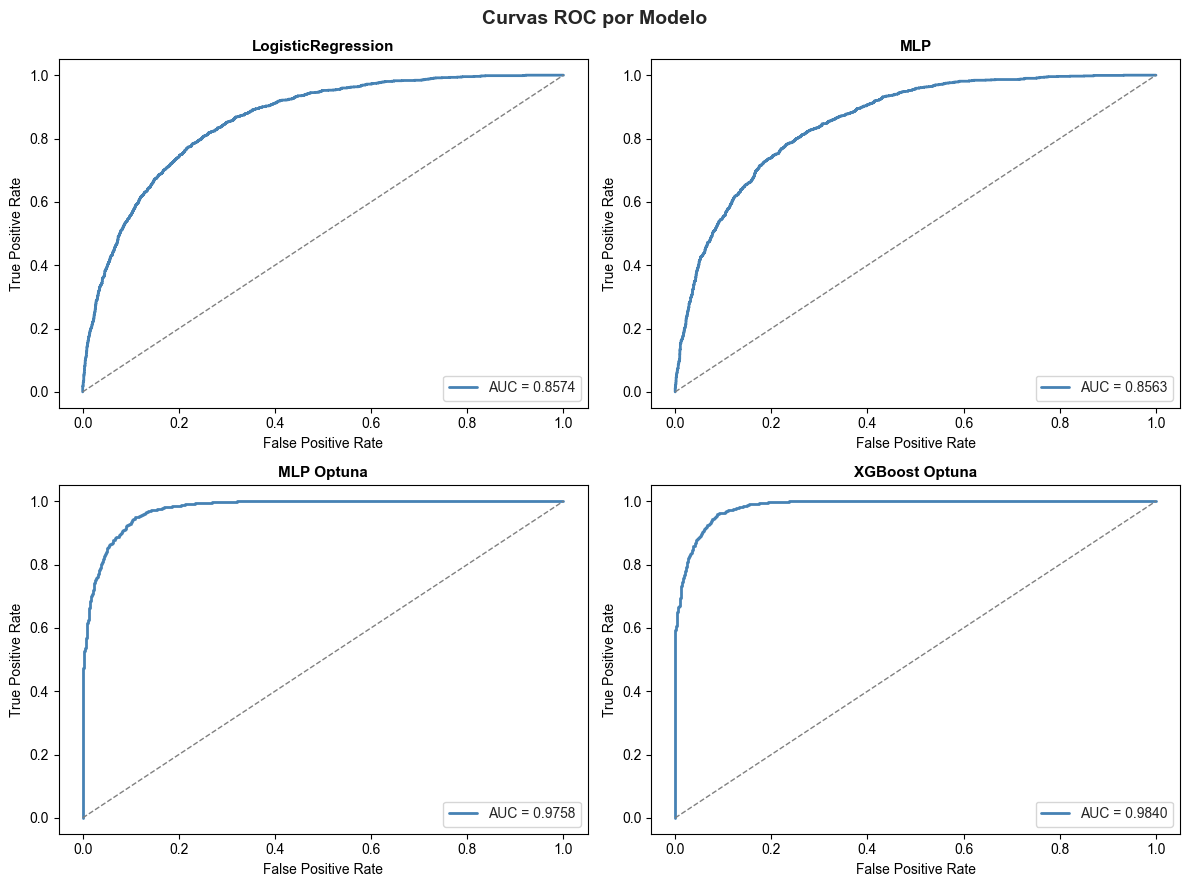

In [10]:
roc_fig = plot_roc_curves_grid(oof_predictions, show=True)


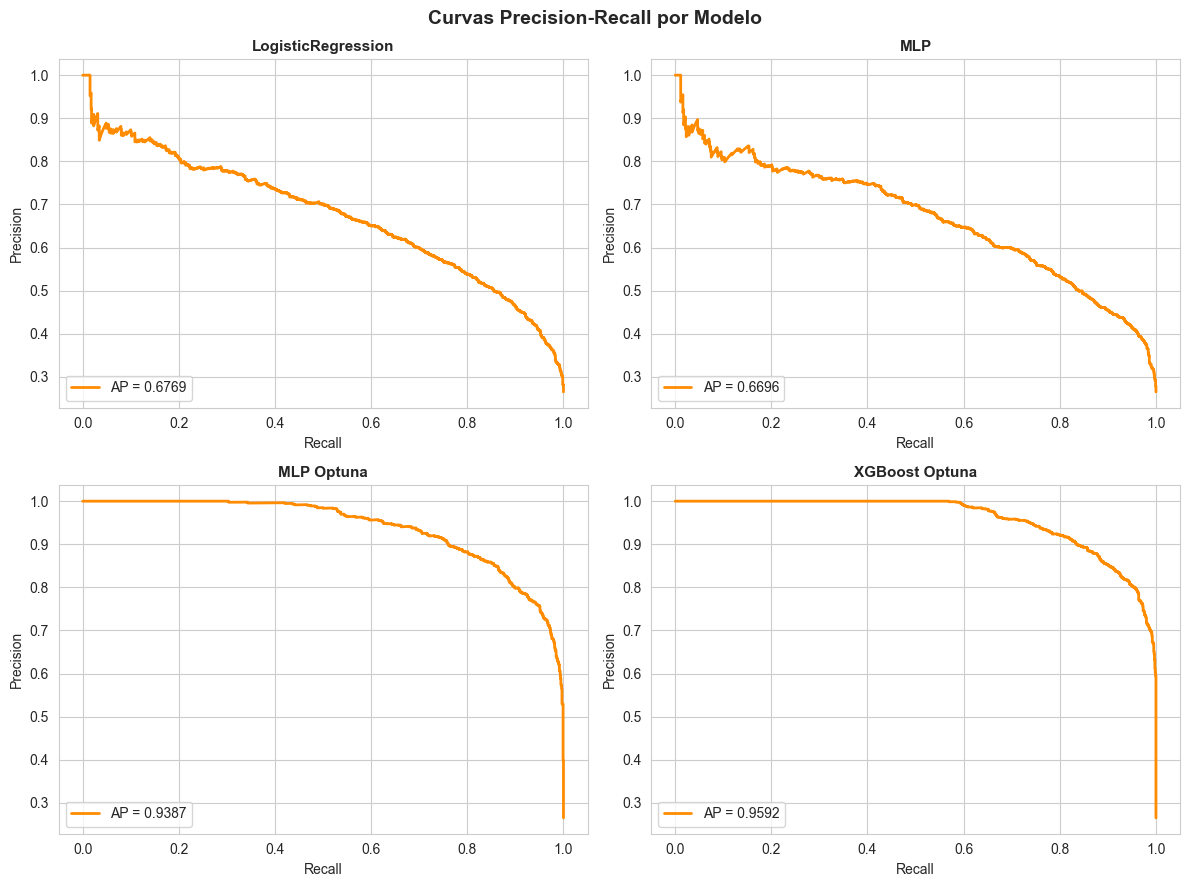

In [11]:
pr_fig = plot_pr_curves_grid(oof_predictions, show=True)


In [12]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['roc_pr'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Curvas ROC e Precision-Recall geradas a partir de probabilidades OOF no conjunto de desenvolvimento.',
    },
):
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03,
        'nb03_curva_roc',
        nested=True,
        tags={**NB03_BASE_TAGS},
    ):
        mlflow.log_artifact(str(save_figure_temp(roc_fig, 'roc_curves_grid.png')))
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03,
        'nb03_curva_pr',
        nested=True,
        tags={**NB03_BASE_TAGS},
    ):
        mlflow.log_artifact(str(save_figure_temp(pr_fig, 'pr_curves_grid.png')))


#### Learning Curves

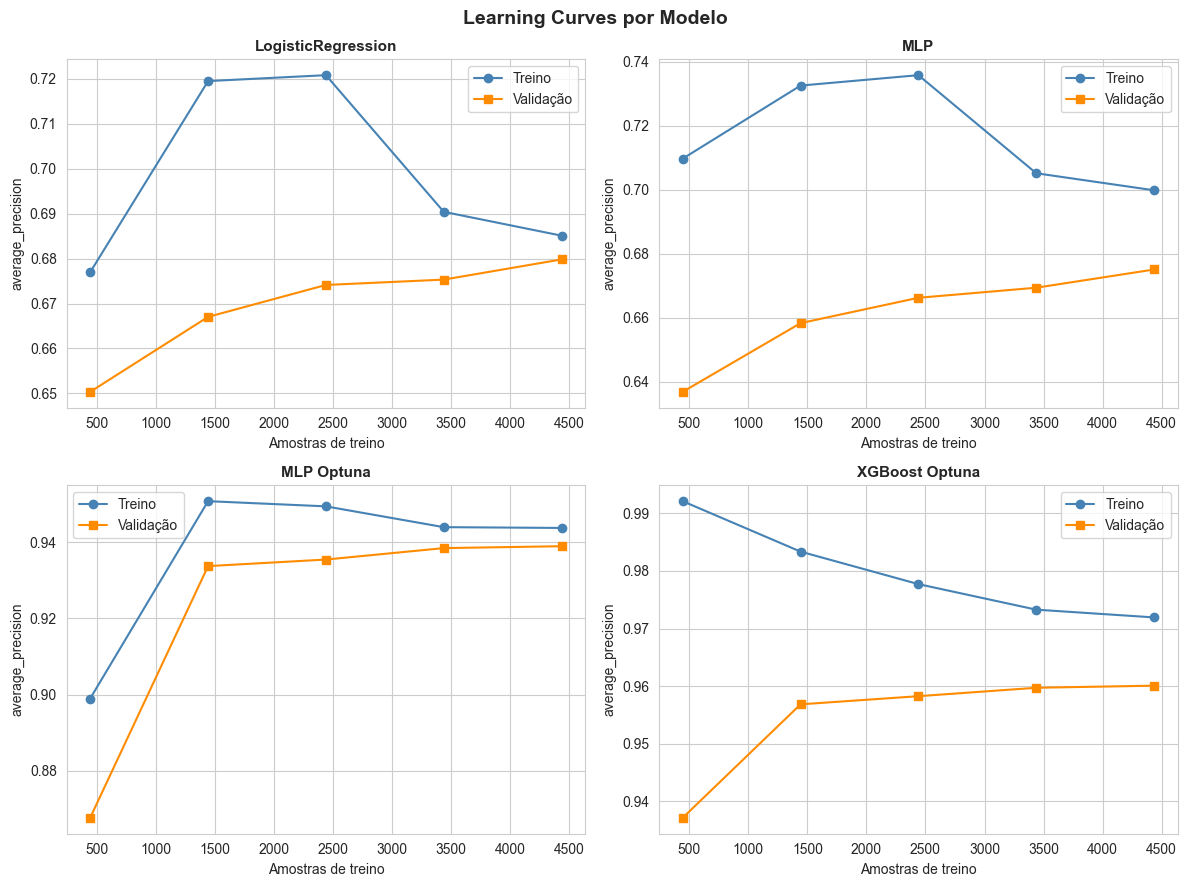

In [13]:
learning_curve_fig = plot_learning_curves_grid(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    show=True,
)


In [14]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['learning'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Learning curves para diagnóstico de comportamento treino vs validação dos modelos comparados.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(learning_curve_fig, 'learning_curves_grid.png')))


### Matriz de Confusão

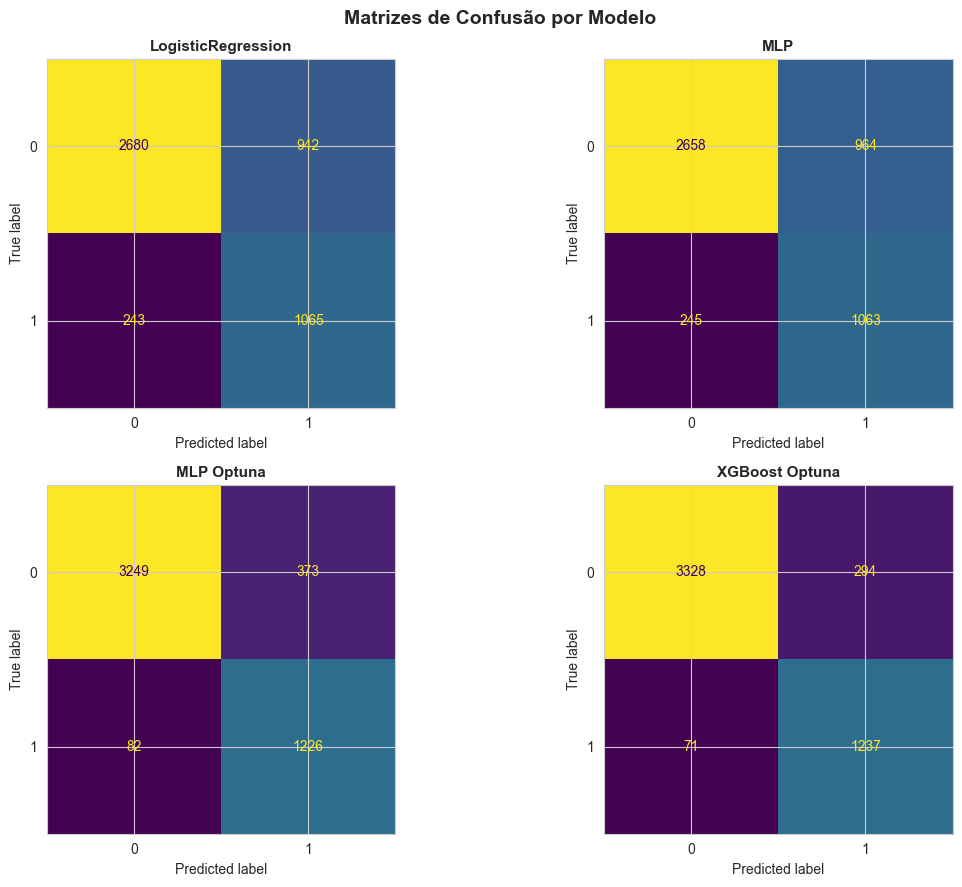

In [15]:
confusion_matrix_fig = plot_confusion_matrices_grid(
    oof_predictions,
    threshold=0.5,
    show=True,
)


In [16]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['confusion'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Matrizes de confusão OOF com threshold padrão de 0.5 para os modelos comparados.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(confusion_matrix_fig, 'confusion_matrices_grid.png')))


### Checagem de Calibração

#### Reliability Curve

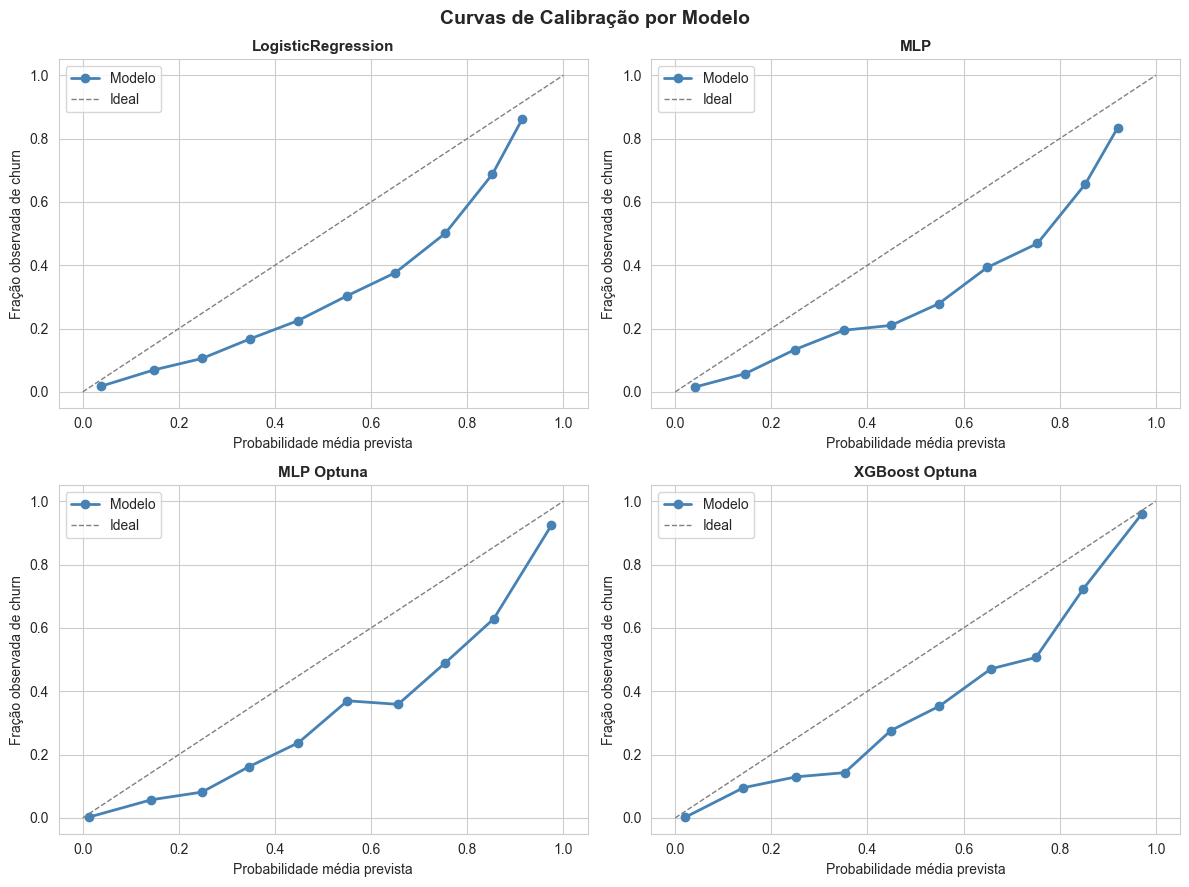

In [17]:
calibration_curve_fig = plot_calibration_curves_grid(
    oof_predictions,
    n_bins=10,
    show=True,
)


In [18]:
calibration_summary = summarize_calibration_for_models(
    oof_predictions,
    n_bins=10,
)

display(calibration_summary.round(6))


,modelo,brier_score,ece
0,LogisticRegression,0.159229,0.141339
1,MLP,0.161715,0.146651
2,MLP Optuna,0.066564,0.064136
3,XGBoost Optuna,0.051794,0.045806


In [19]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['calibration_metrics'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Métricas diagnósticas de calibração (Brier Score e ECE) para os modelos comparados.',
    },
):
    for row in calibration_summary.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_calibration_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'brier_score': row['brier_score'],
                    'ece': row['ece'],
                }
            )


In [20]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['calibration_curve'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Reliability curves geradas a partir das probabilidades OOF dos modelos em comparação.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(calibration_curve_fig, 'calibration_curves_grid.png')))


#### Histograma de probabilidades

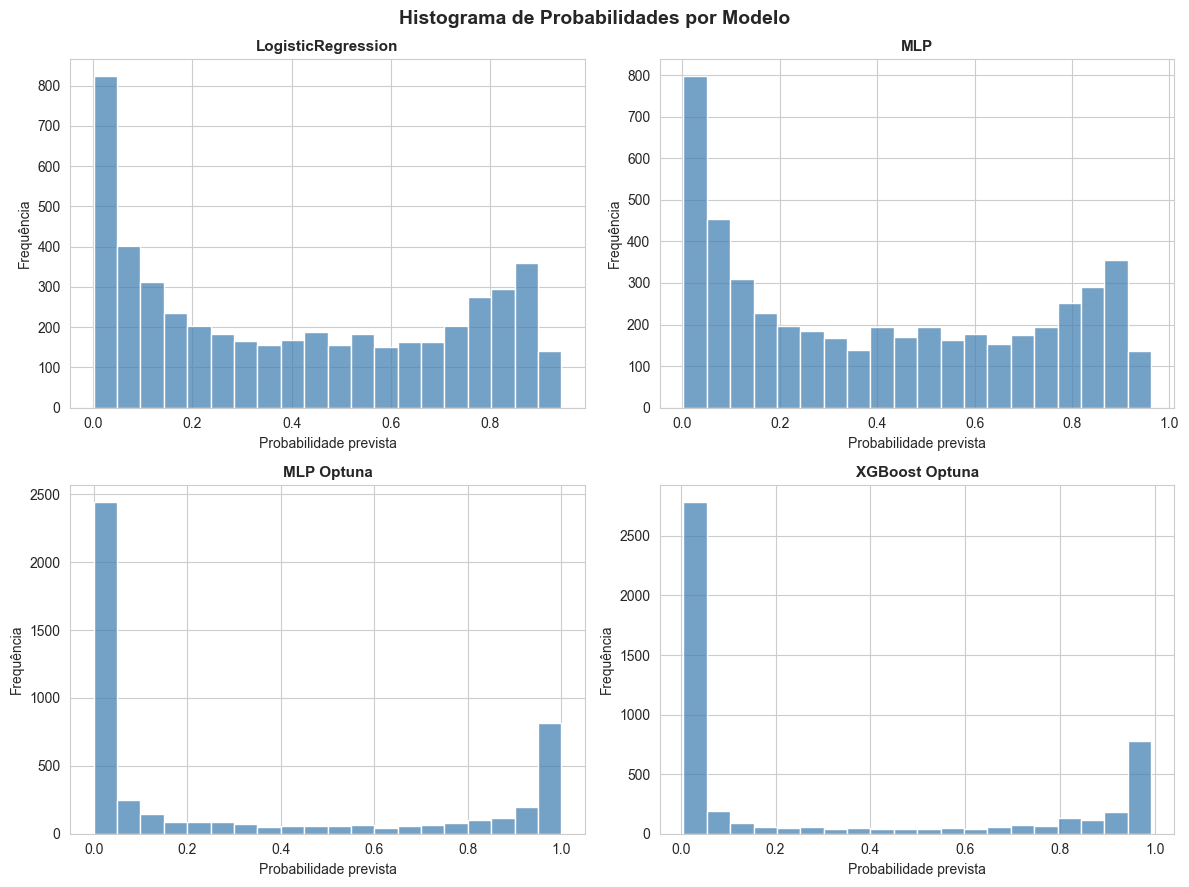

In [21]:
probability_hist_fig = plot_probability_histograms_grid(
    oof_predictions,
    show=True,
)


In [22]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['prob_hist'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Histogramas de probabilidade para inspeção da distribuição dos scores OOF por modelo.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(probability_hist_fig, 'probability_histograms_grid.png')))


### Análise Econômica

#### Cenários a serem explorados

- p puro
- p ajustado por peso/beneficio baseado em `CLTV`

#### Métricas Utilizadas

- IEL - Impacto Economico Liquido
- ROI
- VR - Valor em Risco
- Vrec - Valor Recuperado
- VP - Valor Perdido
- VD - Valor Desperdiçado
- CMCA - Custo Médio por Cliente Acionado

As descrição das métricas podem ser encontradas em `docs/KPI.md`

#### Premissas
- custo_acionamento = 50
- taxa de retençao = 0.1

#### Cenário 1 - probabilidades puro

In [23]:
economic_analysis_pure = build_economic_comparison_table(
    oof_predictions,
    metadata=metadata_train_val,
    activation_cost=ACTIVATION_COST,
    retention_rate=RETENTION_RATE,
    threshold=0.5,
)

display(economic_analysis_pure.round(2))


,modelo,tp,fp,fn,tn,vr,vrec,vp,cmca,total_campaign_cost,vd,iel,roi,threshold,activation_cost,retention_rate
0,XGBoost Optuna,1237,294,71,3328,4710069.07,471006.91,98257.74,50.0,76550.0,14700.0,296199.17,3.87,0.5,50.0,0.1
1,MLP Optuna,1226,373,82,3249,4712636.33,471263.63,114435.63,50.0,79950.0,18650.0,276878.00,3.46,0.5,50.0,0.1
2,MLP,1063,964,245,2658,3471006.63,347100.66,326064.86,50.0,101350.0,48200.0,-80314.20,-0.79,0.5,50.0,0.1
3,LogisticRegression,1065,942,243,2680,3429784.50,342978.45,325701.04,50.0,100350.0,47100.0,-83072.59,-0.83,0.5,50.0,0.1


In [24]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['economics_pure'],
    tags={
        **NB03_BASE_TAGS,
        'scenario': 'p_puro',
        'mlflow.note.content': 'Analise economica com probabilidades OOF puras usando custo por acionamento fixado em 50 BRL e taxa de retenção de 10%.',
    },
):
    log_dataframe_artifact(economic_analysis_pure.round(6), 'economic_analysis_puro.csv')
    for row in economic_analysis_pure.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_economics_pure_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'scenario': 'p_puro',
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'iel': row['iel'],
                    'roi': row['roi'],
                    'vr': row['vr'],
                    'vrec': row['vrec'],
                    'vp': row['vp'],
                    'vd': row['vd'],
                    'total_campaign_cost': row['total_campaign_cost'],
                    'activation_cost': row['activation_cost'],
                }
            )
            log_dataframe_artifact(
                oof_predictions[model_name].copy(),
                build_artifact_name('oof_prob', model_name, 'csv'),
            )


#### Cenário 2 - probabilidades ponderadas por CLTV

In [25]:
cltv_sample_weight = metadata_train_val.loc[X_train_val.index, 'CLTV']

oof_predictions_cltv = generate_oof_predictions_by_model(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    sample_weight=cltv_sample_weight,
)

{
    model_name: oof_df.head()
    for model_name, oof_df in oof_predictions_cltv.items()
}


{'LogisticRegression':    row_index  fold  y_true     proba  pred_0_5               model
 0          0     6       1  0.621886         1  LogisticRegression
 1          1    10       1  0.551513         1  LogisticRegression
 2          2     8       1  0.678326         1  LogisticRegression
 3          4     2       1  0.325361         0  LogisticRegression
 4          6     1       1  0.890667         1  LogisticRegression,
 'MLP':    row_index  fold  y_true     proba  pred_0_5 model
 0          0     6       1  0.566376         1   MLP
 1          1    10       1  0.715329         1   MLP
 2          2     8       1  0.752766         1   MLP
 3          4     2       1  0.221433         0   MLP
 4          6     1       1  0.877375         1   MLP,
 'MLP Optuna':    row_index  fold  y_true     proba  pred_0_5       model
 0          0     6       1  0.978610         1  MLP Optuna
 1          1    10       1  0.704937         1  MLP Optuna
 2          2     8       1  0.986375      

In [26]:
economic_analysis_cltv = build_economic_comparison_table(
    oof_predictions_cltv,
    metadata=metadata_train_val,
    activation_cost=ACTIVATION_COST,
    retention_rate=RETENTION_RATE,
    threshold=0.5,
)

display(economic_analysis_cltv.round(2))


,modelo,tp,fp,fn,tn,vr,vrec,vp,cmca,total_campaign_cost,vd,iel,roi,threshold,activation_cost,retention_rate
0,XGBoost Optuna,1235,293,73,3329,4717900.08,471790.01,96769.84,50.0,76400.0,14650.0,298620.17,3.91,0.5,50.0,0.1
1,MLP Optuna,1225,363,83,3259,4712066.81,471206.68,116074.11,50.0,79400.0,18150.0,275732.57,3.47,0.5,50.0,0.1
2,LogisticRegression,1079,990,229,2632,3517173.56,351717.36,306837.69,50.0,103450.0,49500.0,-58570.33,-0.57,0.5,50.0,0.1
3,MLP,1052,926,256,2696,3429552.60,342955.26,349234.90,50.0,98900.0,46300.0,-105179.64,-1.06,0.5,50.0,0.1


In [27]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['economics_cltv'],
    tags={
        **NB03_BASE_TAGS,
        'scenario': 'p_ponderado_cltv',
        'mlflow.note.content': 'Analise economica com probabilidades OOF geradas a partir de treino ponderado por CLTV via sample_weight usando custo por acionamento fixado em 50 BRL.',
    },
):
    log_dataframe_artifact(economic_analysis_cltv.round(6), 'economic_analysis_cltv_weighted.csv')
    for row in economic_analysis_cltv.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_economics_cltv_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'scenario': 'p_ponderado_cltv',
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'iel': row['iel'],
                    'roi': row['roi'],
                    'vr': row['vr'],
                    'vrec': row['vrec'],
                    'vp': row['vp'],
                    'vd': row['vd'],
                    'total_campaign_cost': row['total_campaign_cost'],
                    'activation_cost': row['activation_cost'],
                }
            )
            log_dataframe_artifact(
                oof_predictions_cltv[model_name].copy(),
                build_artifact_name('oof_prob_cltv', model_name, 'csv'),
            )


#### Conclusão

- Nota-se uma pequena melhora operacional em FP e VD, porém não foi suficiente;
- O modelo deixa passar mais churns valiosos (FN subiu e VP subiu bastante);
- a ponderação por sample_weight não ajudou de forma consistente, o cenário p puro é melhor;
- a ponderação trouxe resultados positivos em outros modelos como a regressão logística, o que sugere que o efeito depende muito da arquitetura.
- a recomendação final é manter a abordagem p puro e utilizar CLTV na priorização da campanha por rankeamento de score;

## Performance do Modelo MLP (produção)

In [28]:
MLFLOW_EXPERIMENT_NB03_PROD = 'tc-f1-nb03-MLP-production-performance'
ensure_experiment(MLFLOW_EXPERIMENT_NB03_PROD)

NB03_PROD_BASE_TAGS = {
    'source_notebook': '03_modelo_mvp',
    'phase': 'production_simulation',
    'comparison_scope': 'holdout',
    'model_name': 'MLP Optuna',
    'upstream_run_id': run_registry['mlp_optuna'].info.run_id,
}

NB03_PROD_RUN_NAMES = {
    'threshold': 'nb03_mlp_threshold_optimization',
    'stress_heatmap': 'nb03_mlp_campaign_retention_roi_heatmap',
    'holdout': 'nb03_mlp_holdout_performance',
    'shap': 'nb03_mlp_holdout_shap',
    'fairness': 'nb03_mlp_holdout_fairness',
}

mlp_optuna_estimator = comparison_models['MLP Optuna']
mlp_optuna_oof = oof_predictions['MLP Optuna'].copy()
mlp_optuna_cltv = metadata_train_val.loc[mlp_optuna_oof['row_index'], 'CLTV'].to_numpy(dtype=float)

production_run_blueprint = pd.DataFrame(
    [
        {'bloco': key, 'run_name': value}
        for key, value in NB03_PROD_RUN_NAMES.items()
    ]
)

display(production_run_blueprint)


,bloco,run_name
0,threshold,nb03_mlp_threshold_optimization
1,stress_heatmap,nb03_mlp_campaign_retention_roi_heatmap
2,holdout,nb03_mlp_holdout_performance
3,shap,nb03_mlp_holdout_shap
4,fairness,nb03_mlp_holdout_fairness


### Otimização do Threshold

In [29]:
threshold_search_df, best_threshold_row = optimize_threshold_for_roi(
    y_true=mlp_optuna_oof['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_oof['proba'].to_numpy(dtype=float),
    cltv=mlp_optuna_cltv,
    threshold_grid=np.round(np.arange(0.0, 1.01, 0.01), 2),
    activation_cost=ACTIVATION_COST,
    retention_rate=RETENTION_RATE,
)

best_threshold = float(best_threshold_row['threshold'])
threshold_search_df.head()


,tp,fp,fn,tn,vr,vrec,vp,cmca,total_campaign_cost,vd,iel,roi,threshold,activation_cost,retention_rate,pr_auc,roc_auc,recall,precision,f1_score
0,1308,3622,0,0,4.827072e+06,482707.196574,0.000000,50.0,246500.0,181100.0,236207.196574,0.958244,0.00,50.0,0.1,0.938705,0.975846,1.000000,0.265314,0.419365
1,1307,1758,1,1864,4.827039e+06,482703.853088,33.434863,50.0,153250.0,87900.0,329420.418225,2.149562,0.01,50.0,0.1,0.938705,0.975846,0.999235,0.426427,0.597759
2,1307,1512,1,2110,4.827039e+06,482703.853088,33.434863,50.0,140950.0,75600.0,341720.418225,2.424409,0.02,50.0,0.1,0.938705,0.975846,0.999235,0.463640,0.633390
3,1307,1357,1,2265,4.827039e+06,482703.853088,33.434863,50.0,133200.0,67850.0,349470.418225,2.623652,0.03,50.0,0.1,0.938705,0.975846,0.999235,0.490616,0.658107
4,1307,1252,1,2370,4.827039e+06,482703.853088,33.434863,50.0,127950.0,62600.0,354720.418225,2.772336,0.04,50.0,0.1,0.938705,0.975846,0.999235,0.510746,0.675976


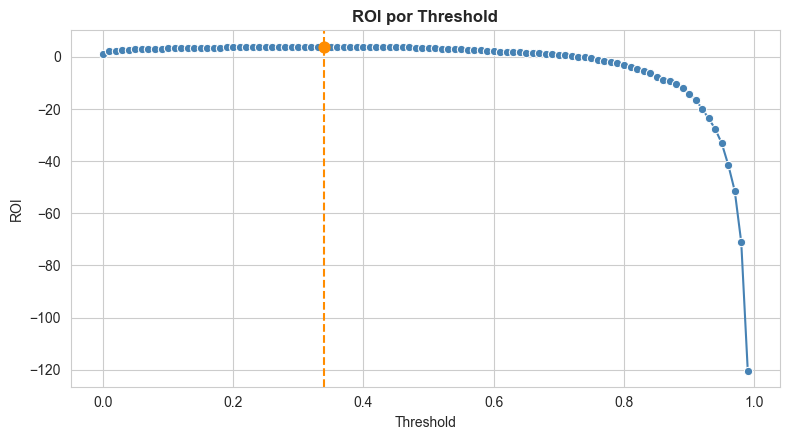

In [30]:
roi_by_threshold_fig = plot_roi_by_threshold(threshold_search_df, show=False)


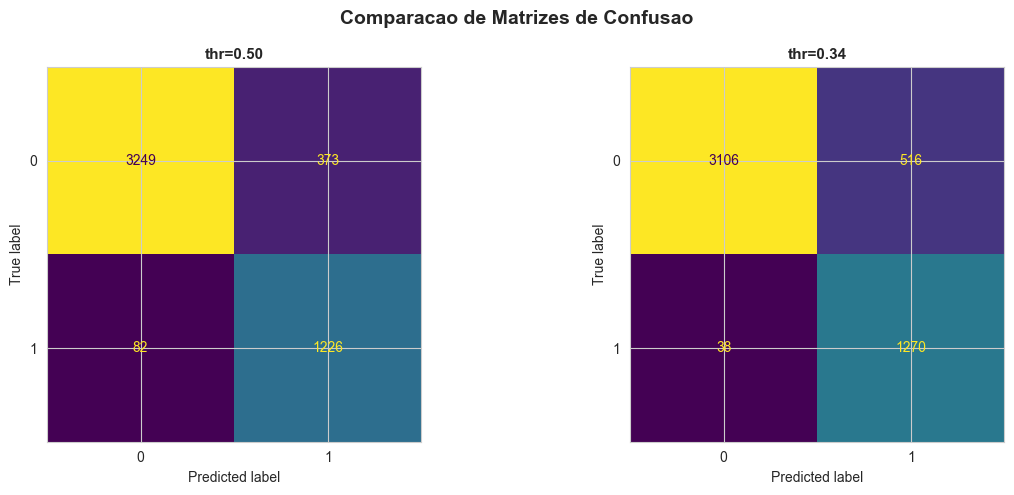

In [31]:
threshold_confusion_fig = plot_confusion_matrix_threshold_comparison(
    mlp_optuna_oof['y_true'].to_numpy(dtype=int),
    mlp_optuna_oof['proba'].to_numpy(dtype=float),
    threshold_a=0.5,
    threshold_b=best_threshold,
    labels=('thr=0.50', f'thr={best_threshold:.2f}'),
    show=False,
)


In [32]:
threshold_best_metrics_df = pd.DataFrame([best_threshold_row]).round(3)
threshold_reference_rows = economic_analysis_pure[
    economic_analysis_pure['modelo'].isin(['LogisticRegression', 'MLP', 'MLP Optuna'])
].copy()
threshold_summary_df = build_threshold_comparison_summary(
    threshold_metrics=best_threshold_row,
    reference_rows=threshold_reference_rows,
).round(3)

display(threshold_best_metrics_df)
display(threshold_summary_df)


,tp,fp,fn,tn,vr,vrec,vp,cmca,total_campaign_cost,vd,iel,roi,threshold,activation_cost,retention_rate,pr_auc,roc_auc,recall,precision,f1_score
34,1270.0,516.0,38.0,3106.0,4794405.839,479440.584,32666.127,50.0,89300.0,25800.0,357474.457,4.003,0.34,50.0,0.1,0.939,0.976,0.971,0.711,0.821


,item,value
0,best_threshold,0.340
1,roi,4.003
2,iel,357474.457
3,vr,4794405.839
4,vrec,479440.584
5,vp,32666.127
6,vd,25800.000
7,pr_auc,0.939
8,roc_auc,0.976
9,recall,0.971


In [33]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['threshold'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'threshold_optimization',
        'mlflow.note.content': 'Otimização do threshold da MLP Optuna com base em ROI no conjunto de desenvolvimento usando custo por acionamento fixado em 50 BRL.',
    },
):
    log_metrics_safe(
        {
            'best_threshold': best_threshold,
            'iel': float(best_threshold_row['iel']),
            'roi': float(best_threshold_row['roi']),
            'vr': float(best_threshold_row['vr']),
            'vrec': float(best_threshold_row['vrec']),
            'vp': float(best_threshold_row['vp']),
            'vd': float(best_threshold_row['vd']),
            'total_campaign_cost': float(best_threshold_row['total_campaign_cost']),
            'activation_cost': float(best_threshold_row['activation_cost']),
            'pr_auc': float(best_threshold_row['pr_auc']),
            'roc_auc': float(best_threshold_row['roc_auc']),
            'recall': float(best_threshold_row['recall']),
            'precision': float(best_threshold_row['precision']),
            'f1_score': float(best_threshold_row['f1_score']),
        }
    )
    log_dataframe_artifact(threshold_search_df.round(6), 'mlp_optuna_threshold_search.csv')
    log_dataframe_artifact(threshold_best_metrics_df.round(6), 'mlp_optuna_best_threshold_metrics.csv')
    log_dataframe_artifact(threshold_summary_df.round(6), 'mlp_optuna_threshold_summary.csv')
    mlflow.log_artifact(str(save_figure_temp(roi_by_threshold_fig, 'mlp_optuna_roi_by_threshold.png')))
    mlflow.log_artifact(
        str(
            save_figure_temp(
                threshold_confusion_fig,
                'mlp_optuna_confusion_threshold_compare.png',
            )
        )
    )


### Campanha x Retenção x ROI (heatmap)

In [34]:
activation_cost_grid = [25, 50, 75, 100, 125, 150]
retencao = [0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]


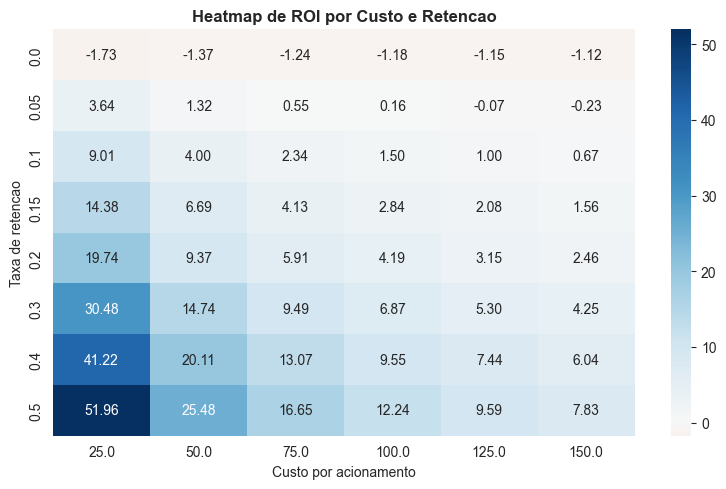

In [35]:
campaign_retention_roi_grid = build_campaign_retention_roi_grid(
    y_true=mlp_optuna_oof['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_oof['proba'].to_numpy(dtype=float),
    cltv=mlp_optuna_cltv,
    threshold=best_threshold,
    activation_cost_values=activation_cost_grid,
    retention_values=retencao,
)

campaign_retention_roi_heatmap_fig = plot_roi_heatmap(campaign_retention_roi_grid, show=False)


In [36]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['stress_heatmap'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'stress_test',
        'analysis_type': 'campaign_retention_roi_heatmap',
        'mlflow.note.content': 'Heatmap de ROI da MLP Optuna variando custo por acionamento e taxa de reten??o com threshold ?timo fixado.',
    },
):
    mlflow.log_param('best_threshold', best_threshold)
    log_dataframe_artifact(campaign_retention_roi_grid.round(6), 'mlp_optuna_campaign_retention_roi_grid.csv')
    mlflow.log_artifact(
        str(
            save_figure_temp(
                campaign_retention_roi_heatmap_fig,
                'mlp_optuna_campaign_retention_roi_heatmap.png',
            )
        )
    )


### Análise no Holdout

In [37]:
mlp_optuna_final_estimator, mlp_optuna_holdout = fit_final_estimator_and_generate_predictions(
    estimator=mlp_optuna_estimator,
    X_train=X_train_val,
    y_train=y_train_val,
    X_test=X_test,
    y_test=y_test,
    threshold=best_threshold,
    model_name='MLP Optuna',
)

holdout_technical_metrics = compute_holdout_technical_metrics(
    y_true=mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    threshold=best_threshold,
)
holdout_economic_metrics = build_retention_roi_table(
    y_true=mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    cltv=metadata_test.loc[mlp_optuna_holdout['row_index'], 'CLTV'].to_numpy(dtype=float),
    threshold=best_threshold,
    activation_cost=ACTIVATION_COST,
    retention_values=[RETENTION_RATE],
).iloc[0].to_dict()

selected_feature_names = extract_selected_feature_names(mlp_optuna_final_estimator, X_train_val)
holdout_metrics_df = pd.DataFrame(
    [
        {
            'modelo': 'MLP Optuna',
            'threshold': best_threshold,
            **holdout_technical_metrics,
            **holdout_economic_metrics,
        }
    ]
).round(3)

selected_features_mlp_optuna = pd.DataFrame(
    {
        'feature_rank': np.arange(1, len(selected_feature_names) + 1),
        'feature_name': selected_feature_names,
    }
)

display(holdout_metrics_df)



,modelo,threshold,pr_auc,roc_auc,recall,precision,f1_score,tp,fp,fn,...,vr,vrec,vp,cmca,total_campaign_cost,vd,iel,roi,activation_cost,retention_rate
0,MLP Optuna,0.34,0.94,0.976,0.957,0.713,0.817,537.0,216.0,24.0,...,2011377.159,201137.716,21787.744,50.0,37650.0,10800.0,141699.972,3.764,50.0,0.1


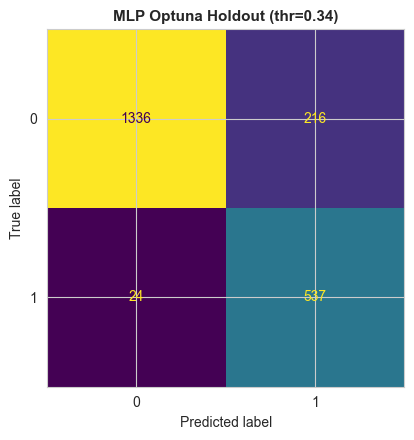

In [38]:
holdout_confusion_fig = plot_single_confusion_matrix(
    mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    mlp_optuna_holdout['y_pred'].to_numpy(dtype=int),
    title=f'MLP Optuna Holdout (thr={best_threshold:.2f})',
    show=False,
)



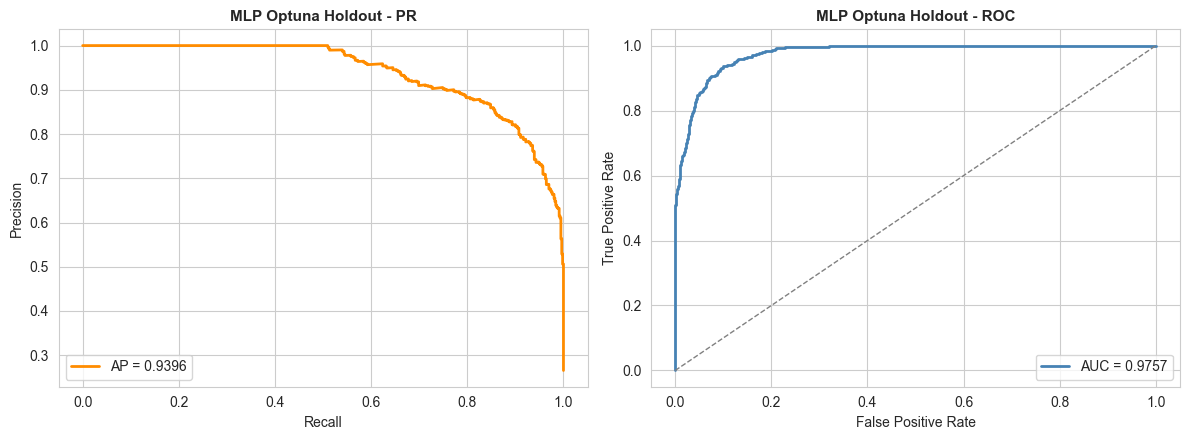

In [39]:
holdout_pr_roc_fig = plot_holdout_pr_roc_subplot(
    mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    title='MLP Optuna Holdout',
    show=False,
)



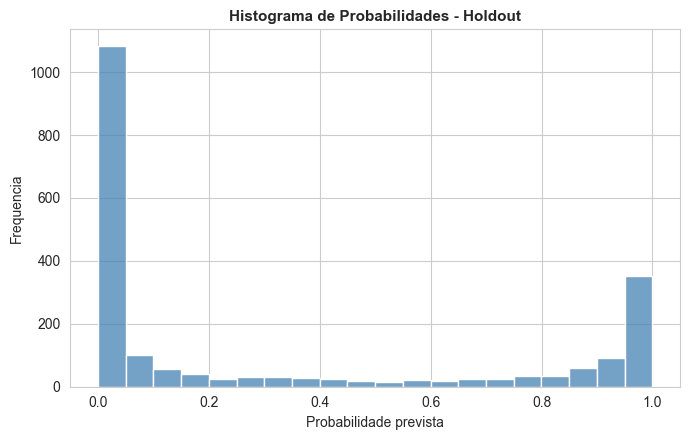

In [40]:
holdout_probability_fig = plot_single_probability_histogram(
    mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    title='Histograma de Probabilidades - Holdout',
    show=False,
)


In [41]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['holdout'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'holdout_evaluation',
        'mlflow.note.content': 'Avaliação final da MLP Optuna no holdout com threshold ótimo fixado e custo por acionamento de 50 BRL.',
    },
):
    log_metrics_safe(
        {
            'best_threshold': best_threshold,
            'pr_auc': float(holdout_technical_metrics['pr_auc']),
            'roc_auc': float(holdout_technical_metrics['roc_auc']),
            'recall': float(holdout_technical_metrics['recall']),
            'precision': float(holdout_technical_metrics['precision']),
            'f1_score': float(holdout_technical_metrics['f1_score']),
            'iel': float(holdout_economic_metrics['iel']),
            'roi': float(holdout_economic_metrics['roi']),
            'vr': float(holdout_economic_metrics['vr']),
            'vrec': float(holdout_economic_metrics['vrec']),
            'vp': float(holdout_economic_metrics['vp']),
            'vd': float(holdout_economic_metrics['vd']),
            'total_campaign_cost': float(holdout_economic_metrics['total_campaign_cost']),
            'activation_cost': float(holdout_economic_metrics['activation_cost']),
        }
    )
    log_dataframe_artifact(holdout_metrics_df.round(6), 'mlp_optuna_holdout_metrics.csv')
    log_dataframe_artifact(selected_features_mlp_optuna, 'mlp_optuna_selected_features.csv')
    log_dataframe_artifact(mlp_optuna_holdout.round(6), 'mlp_optuna_holdout_predictions.csv')
    mlflow.log_artifact(str(save_figure_temp(holdout_confusion_fig, 'mlp_optuna_holdout_confusion_matrix.png')))
    mlflow.log_artifact(str(save_figure_temp(holdout_pr_roc_fig, 'mlp_optuna_holdout_pr_roc.png')))
    mlflow.log_artifact(str(save_figure_temp(holdout_probability_fig, 'mlp_optuna_holdout_probability_hist.png')))


### Interpretabilidade da Rede Neural (SHAP)

  0%|          | 0/200 [00:00<?, ?it/s]

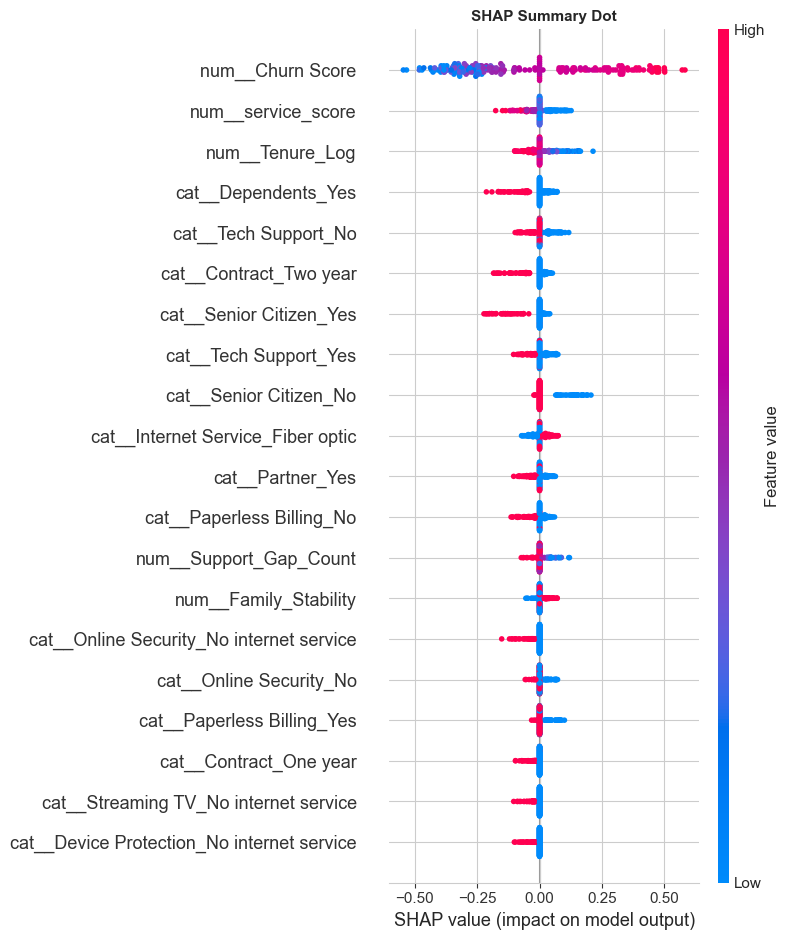

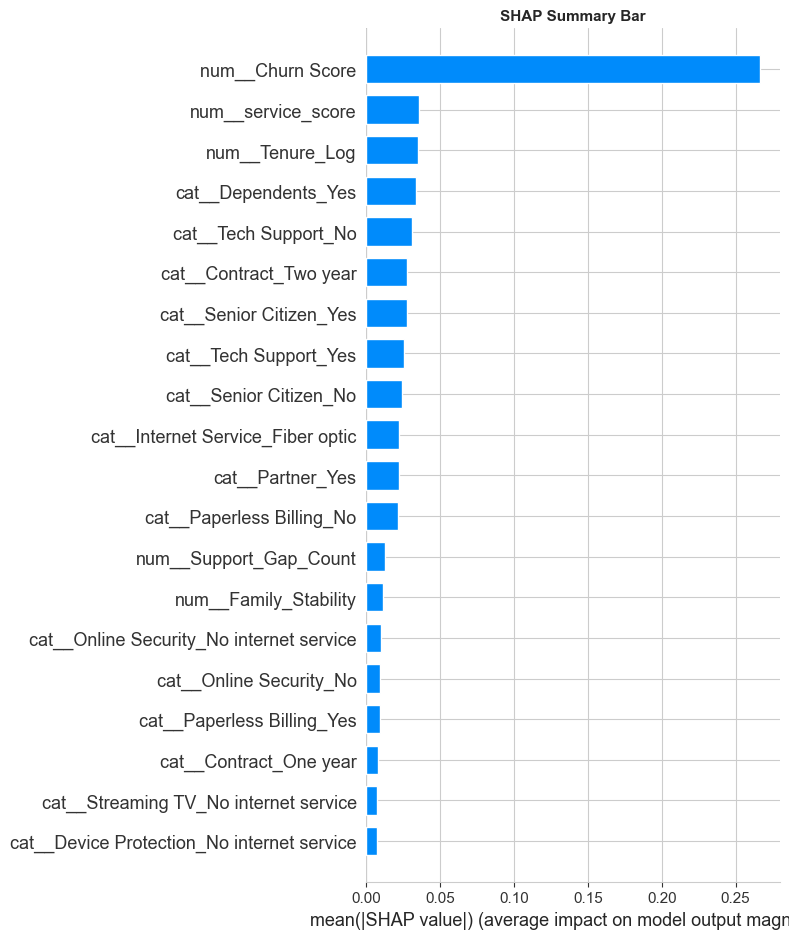

In [55]:
try:
    shap_payload = compute_shap_summary_payload(
        fitted_estimator=mlp_optuna_final_estimator,
        X_reference=X_train_val,
        sample_size=min(200, len(X_train_val)),
        background_size=50,
        random_state=42,
    )
    shap_dot_fig, shap_bar_fig = plot_shap_summary_figures(
        shap_payload['shap_values'],
        shap_payload['transformed_values'],
        shap_payload['feature_names'],
        show=False,
    )

except ModuleNotFoundError as exc:
    shap_payload = None
    shap_dot_fig = None
    shap_bar_fig = None
    print(str(exc))


In [43]:
if shap_dot_fig is None or shap_bar_fig is None:
    print('SHAP n?o foi logado porque a depend?ncia n?o est? dispon?vel no ambiente atual.')
else:
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03_PROD,
        NB03_PROD_RUN_NAMES['shap'],
        tags={
            **NB03_PROD_BASE_TAGS,
            'stage': 'holdout_explainability',
            'mlflow.note.content': 'Explicabilidade do modelo final MLP Optuna no holdout usando SHAP sobre a representa??o transformada do pipeline.',
        },
    ):
        mlflow.log_artifact(str(save_figure_temp(shap_dot_fig, 'mlp_optuna_holdout_shap_summary_dot.png')))
        mlflow.log_artifact(str(save_figure_temp(shap_bar_fig, 'mlp_optuna_holdout_shap_summary_bar.png')))


### Análise de Fairness

In [44]:
fairness_features = ['Senior Citizen', 'Partner', 'Dependents', 'Contract']
fairness_reports = build_fairness_reports_bundle(
    y_true=mlp_optuna_holdout['y_true'],
    y_pred=mlp_optuna_holdout['y_pred'],
    X_sensitive=X_test[fairness_features],
    features=fairness_features,
)

fairness_by_group_df, fairness_summary_df = consolidate_fairness_reports(fairness_reports)


In [45]:
for feature_name in fairness_features:
    print(f'Feature: {feature_name}')
    display(fairness_reports[feature_name]['by_group'].round(6))
    display(fairness_reports[feature_name]['summary'].round(6))
    display(fairness_reports[feature_name]['fairness_metrics'].round(6))


Feature: Senior Citizen


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,No,1765,0.321246,0.948905,0.687831,0.797546,0.130724,0.051095
1,Yes,348,0.534483,0.980000,0.790323,0.875000,0.196970,0.020000


,metric,difference,ratio
0,selection_rate,0.213236,0.601042
1,recall,0.031095,0.968271
2,precision,0.102492,0.870316
3,f1_score,0.077454,0.911481
4,fpr,0.066246,0.663675
5,fnr,0.031095,0.391429


,metric,value
0,demographic_parity_difference,0.213236
1,equalized_odds_difference,0.066246
2,equalized_odds_ratio,0.663675


Feature: Partner


...

,metric,value
0,demographic_parity_difference,0.332193
1,equalized_odds_difference,0.214617
2,equalized_odds_ratio,0.254642


Feature: Contract


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,Month-to-month,1171,0.559351,0.971774,0.735878,0.837533,0.256296,0.028226
1,One year,439,0.179954,0.886792,0.594937,0.712121,0.082902,0.113208
2,Two year,503,0.037773,0.666667,0.421053,0.516129,0.022403,0.333333


,metric,difference,ratio
0,selection_rate,0.521578,0.067531
1,recall,0.305108,0.686030
2,precision,0.314825,0.572177
3,f1_score,0.321404,0.616249
4,fpr,0.233893,0.087412
5,fnr,0.305108,0.084677


,metric,value
0,demographic_parity_difference,0.521578
1,equalized_odds_difference,0.305108
2,equalized_odds_ratio,0.087412


Fairness - Senior Citizen


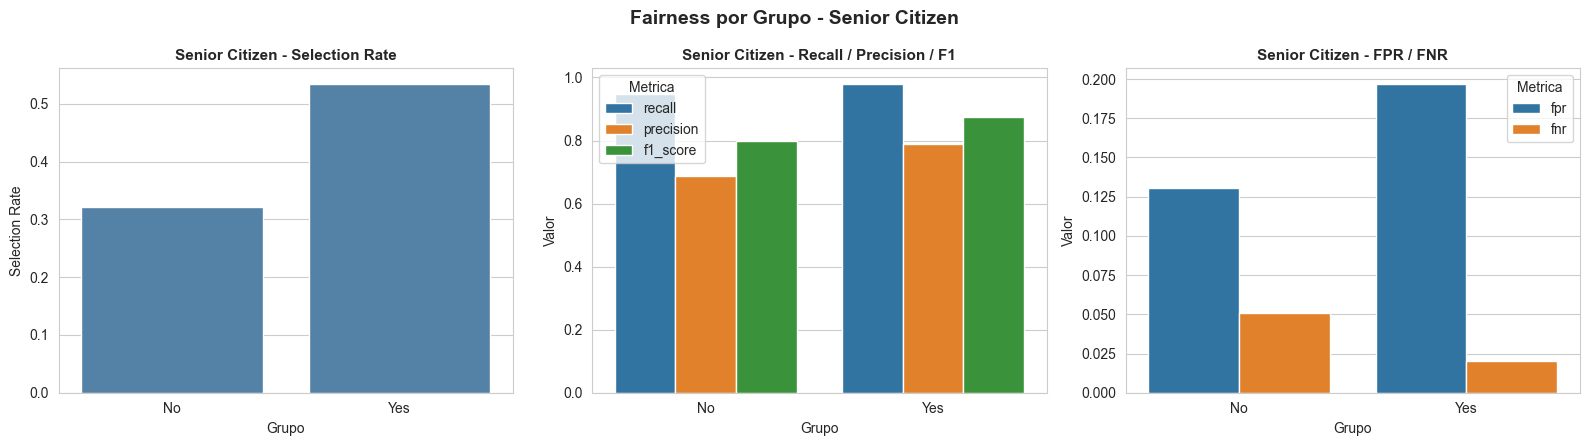

Fairness - Partner


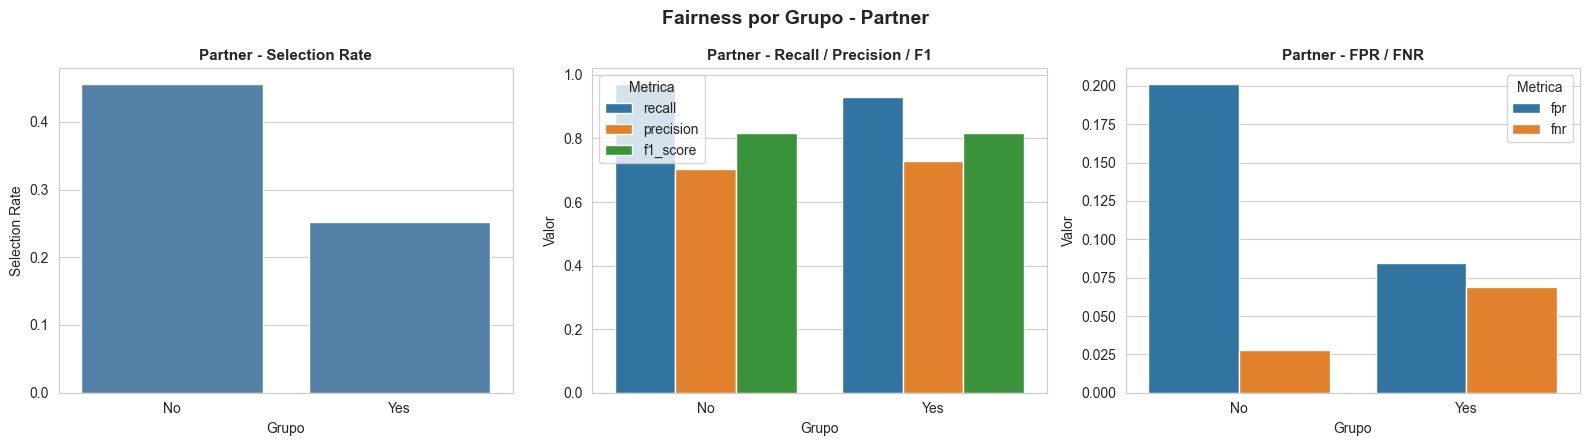

Fairness - Dependents


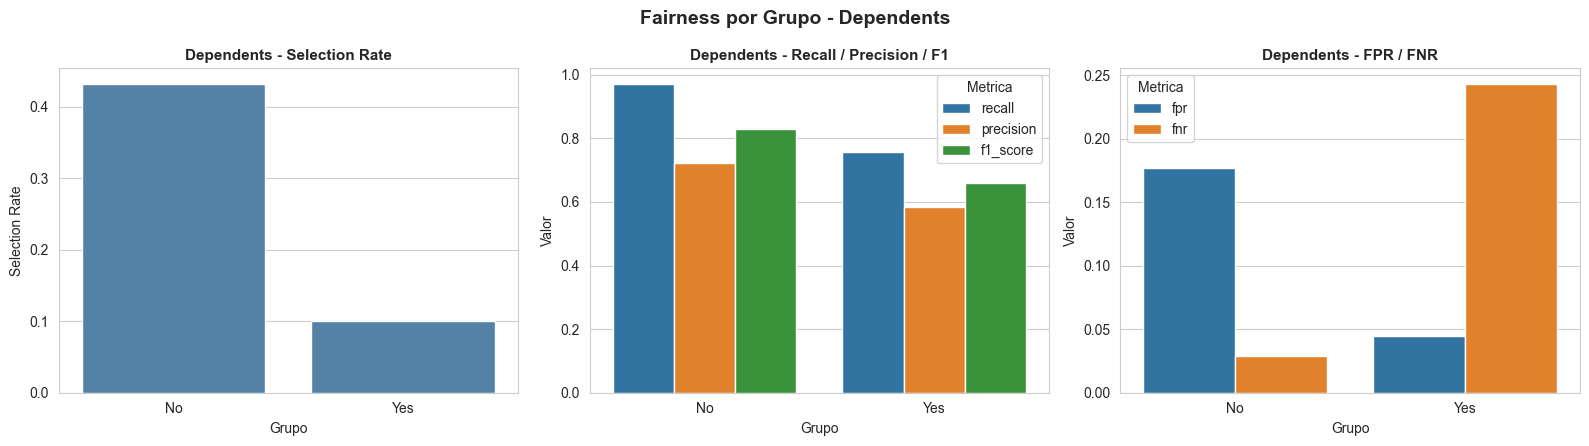

Fairness - Contract


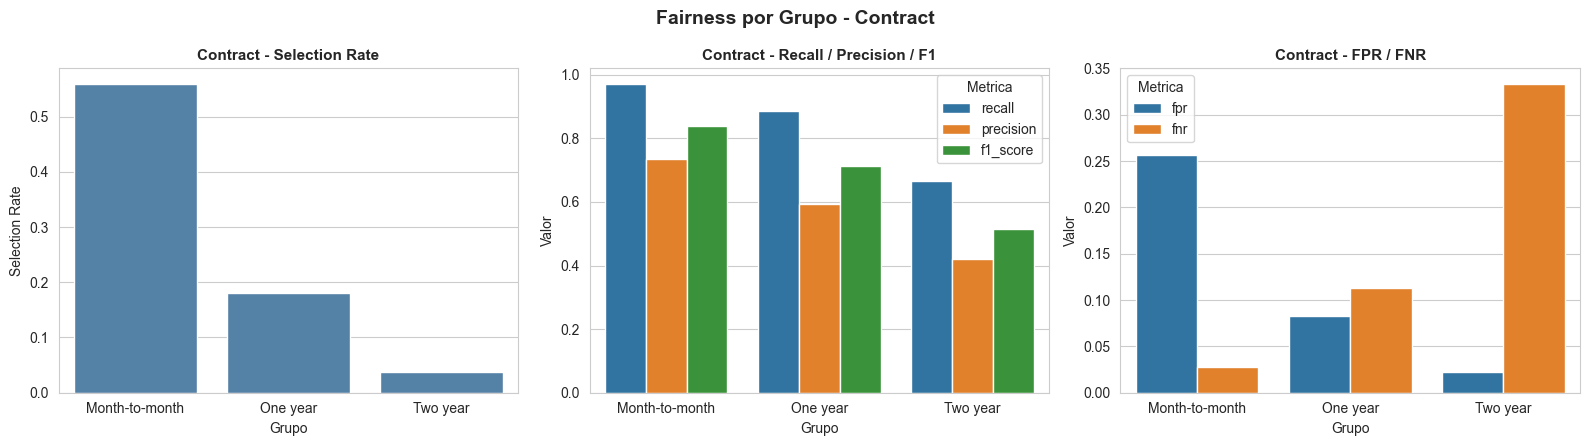

In [46]:
fairness_figures = {
    feature_name: plot_fairness_feature_subplot(
        report['by_group'],
        feature_name=feature_name,
        show=False,
    )
    for feature_name, report in fairness_reports.items()
}

for feature_name, fig in fairness_figures.items():
    print(f'Fairness - {feature_name}')
    display(fig)
    plt.close(fig)


In [47]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['fairness'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'holdout_fairness',
        'mlflow.note.content': 'Análise de fairness por grupos sensíveis e contratuais para a MLP Optuna no holdout final, com artefatos separados por feature.',
    },
):
    for feature_name, report in fairness_reports.items():
        feature_slug = feature_name.lower().replace(' ', '_')
        log_dataframe_artifact(
            report['by_group'].round(6),
            f'mlp_optuna_fairness_{feature_slug}_by_group.csv',
        )
        log_dataframe_artifact(
            report['summary'].round(6),
            f'mlp_optuna_fairness_{feature_slug}_summary.csv',
        )
        log_dataframe_artifact(
            report['fairness_metrics'].round(6),
            f'mlp_optuna_fairness_{feature_slug}_metrics.csv',
        )

    log_dataframe_artifact(fairness_by_group_df.round(6), 'mlp_optuna_fairness_by_group_consolidated.csv')
    log_dataframe_artifact(fairness_summary_df.round(6), 'mlp_optuna_fairness_summary_consolidated.csv')


In [48]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    f"{NB03_PROD_RUN_NAMES['fairness']}_plots",
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'holdout_fairness',
        'artifact_type': 'plots',
    },
):
    for feature_name, fig in fairness_figures.items():
        feature_slug = feature_name.lower().replace(' ', '_')
        mlflow.log_artifact(
            str(save_figure_temp(fig, f'mlp_optuna_fairness_{feature_slug}.png'))
        )


#### Fairness Comparativo com thr=0.5 e 0.35

In [51]:
threshold_fairness_baseline = 0.5

mlp_optuna_holdout_05 = mlp_optuna_holdout.copy()
mlp_optuna_holdout_05["y_pred"] = (
    mlp_optuna_holdout_05["proba"].to_numpy(dtype=float) >= threshold_fairness_baseline
).astype(int)
mlp_optuna_holdout_05["threshold"] = threshold_fairness_baseline

fairness_features = ["Senior Citizen", "Partner", "Dependents", "Contract"]

fairness_reports_05 = build_fairness_reports_bundle(
    y_true=mlp_optuna_holdout_05["y_true"],
    y_pred=mlp_optuna_holdout_05["y_pred"],
    X_sensitive=X_test[fairness_features],
    features=fairness_features,
)

fairness_by_group_05, fairness_summary_05 = consolidate_fairness_reports(
    fairness_reports_05
)



In [50]:
feature_name = "Senior Citizen"

print("Threshold ótimo")
display(fairness_reports[feature_name]["by_group"].round(6))
display(fairness_reports[feature_name]["fairness_metrics"].round(6))

print("Threshold 0.5")
display(fairness_reports_05[feature_name]["by_group"].round(6))
display(fairness_reports_05[feature_name]["fairness_metrics"].round(6))


Threshold ótimo


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,No,1765,0.321246,0.948905,0.687831,0.797546,0.130724,0.051095
1,Yes,348,0.534483,0.980000,0.790323,0.875000,0.196970,0.020000


,metric,value
0,demographic_parity_difference,0.213236
1,equalized_odds_difference,0.066246
2,equalized_odds_ratio,0.663675


Threshold 0.5


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,No,1765,0.286119,0.924574,0.752475,0.829694,0.092319,0.075426
1,Yes,348,0.491379,0.953333,0.836257,0.890966,0.141414,0.046667


,metric,value
0,demographic_parity_difference,0.205260
1,equalized_odds_difference,0.049095
2,equalized_odds_ratio,0.652828


In [52]:
feature_name = "Partner"

print("Threshold ótimo")
display(fairness_reports[feature_name]["by_group"].round(6))
display(fairness_reports[feature_name]["fairness_metrics"].round(6))

print("Threshold 0.5")
display(fairness_reports_05[feature_name]["by_group"].round(6))
display(fairness_reports_05[feature_name]["fairness_metrics"].round(6))


Threshold ótimo


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,No,1083,0.456140,0.972067,0.704453,0.816901,0.201379,0.027933
1,Yes,1030,0.251456,0.931034,0.729730,0.818182,0.084643,0.068966


,metric,value
0,demographic_parity_difference,0.204684
1,equalized_odds_difference,0.116736
2,equalized_odds_ratio,0.420318


Threshold 0.5


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,No,1083,0.418283,0.955307,0.754967,0.843403,0.153103,0.044693
1,Yes,1030,0.216505,0.891626,0.811659,0.849765,0.050786,0.108374


,metric,value
0,demographic_parity_difference,0.201778
1,equalized_odds_difference,0.102317
2,equalized_odds_ratio,0.331710


In [53]:
feature_name = "Dependents"

print("Threshold ótimo")
display(fairness_reports[feature_name]["by_group"].round(6))
display(fairness_reports[feature_name]["fairness_metrics"].round(6))

print("Threshold 0.5")
display(fairness_reports_05[feature_name]["by_group"].round(6))
display(fairness_reports_05[feature_name]["fairness_metrics"].round(6))


Threshold ótimo


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,No,1632,0.431985,0.971374,0.721986,0.828316,0.176895,0.028626
1,Yes,481,0.099792,0.756757,0.583333,0.658824,0.045045,0.243243


,metric,value
0,demographic_parity_difference,0.332193
1,equalized_odds_difference,0.214617
2,equalized_odds_ratio,0.254642


Threshold 0.5


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,No,1632,0.395221,0.948473,0.770543,0.850299,0.133574,0.051527
1,Yes,481,0.064449,0.702703,0.838710,0.764706,0.011261,0.297297


,metric,value
0,demographic_parity_difference,0.330772
1,equalized_odds_difference,0.245771
2,equalized_odds_ratio,0.084307


In [54]:
feature_name = "Contract"

print("Threshold ótimo")
display(fairness_reports[feature_name]["by_group"].round(6))
display(fairness_reports[feature_name]["fairness_metrics"].round(6))

print("Threshold 0.5")
display(fairness_reports_05[feature_name]["by_group"].round(6))
display(fairness_reports_05[feature_name]["fairness_metrics"].round(6))


Threshold ótimo


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,Month-to-month,1171,0.559351,0.971774,0.735878,0.837533,0.256296,0.028226
1,One year,439,0.179954,0.886792,0.594937,0.712121,0.082902,0.113208
2,Two year,503,0.037773,0.666667,0.421053,0.516129,0.022403,0.333333


,metric,value
0,demographic_parity_difference,0.521578
1,equalized_odds_difference,0.305108
2,equalized_odds_ratio,0.087412


Threshold 0.5


,group,support,selection_rate,recall,precision,f1_score,fpr,fnr
0,Month-to-month,1171,0.514944,0.949597,0.781095,0.857143,0.195556,0.050403
1,One year,439,0.136674,0.849057,0.750000,0.796460,0.038860,0.150943
2,Two year,503,0.025845,0.583333,0.538462,0.560000,0.012220,0.416667


,metric,value
0,demographic_parity_difference,0.489100
1,equalized_odds_difference,0.366263
2,equalized_odds_ratio,0.062488


#### Conclusão

- com threshold 0.5 a conclusão praticamente se mantém a mesmo com relação ao threshold 0.35.
- aparentemente não foi o threshold que criou o problema, os desalinhamentos já existem também em 0.5;
- `Senior Citizen` -> Monitorar, sem mitigação;
- `Partner` -> Vale abrir uma investigação mais profunda, mas não traria como prioridade máxima de mitigação (dado menos sensível);
- `Dependents`-> sinal forte de tratamento desigual. Aqui vale a pela considerar mitigação ou análise profunda antes de produção;
- `Contract`-> Definiria com risco de performance por segmento (limitações e vieses).

### Serialização do Modelo Final para Produção

In [57]:
PRODUCTION_THRESHOLD = 0.35
PRODUCTION_RUN_NAME = "nb03_mlp_production_model_threshold_035"

# Recria a MLP final com o threshold de produção embutido no wrapper
mlp_optuna_estimator_prod = comparison_models["MLP Optuna"].set_params(
    model__threshold=PRODUCTION_THRESHOLD
)

# Refit final no train_val inteiro e geração das predições no holdout
mlp_optuna_production_model, mlp_optuna_holdout_prod = fit_final_estimator_and_generate_predictions(
    estimator=mlp_optuna_estimator_prod,
    X_train=X_train_val,
    y_train=y_train_val,
    X_test=X_test,
    y_test=y_test,
    threshold=PRODUCTION_THRESHOLD,
    model_name="MLP Optuna",
)

# Métricas técnicas no holdout
holdout_technical_metrics_prod = compute_holdout_technical_metrics(
    y_true=mlp_optuna_holdout_prod["y_true"].to_numpy(dtype=int),
    y_prob=mlp_optuna_holdout_prod["proba"].to_numpy(dtype=float),
    threshold=PRODUCTION_THRESHOLD,
)

# Métricas econômicas no holdout
holdout_economic_metrics_prod = build_retention_roi_table(
    y_true=mlp_optuna_holdout_prod["y_true"].to_numpy(dtype=int),
    y_prob=mlp_optuna_holdout_prod["proba"].to_numpy(dtype=float),
    cltv=metadata_test.loc[mlp_optuna_holdout_prod["row_index"], "CLTV"].to_numpy(dtype=float),
    threshold=PRODUCTION_THRESHOLD,
    activation_cost=ACTIVATION_COST,
    retention_values=[RETENTION_RATE],
).iloc[0].to_dict()

# Features finais selecionadas
selected_feature_names_prod = extract_selected_feature_names(
    mlp_optuna_production_model,
    X_train_val,
)

production_metrics_df = pd.DataFrame(
    [
        {
            "modelo": "MLP Optuna",
            "threshold": PRODUCTION_THRESHOLD,
            **holdout_technical_metrics_prod,
            **holdout_economic_metrics_prod,
        }
    ]
).round(6)

production_config_df = pd.DataFrame(
    [
        {
            "model_name": "MLP Optuna",
            "threshold": PRODUCTION_THRESHOLD,
            "activation_cost": ACTIVATION_COST,
            "retention_rate": RETENTION_RATE,
            "upstream_run_id": run_registry["mlp_optuna"].info.run_id,
            "source_notebook": "03_modelo_mvp",
            "phase": "production_model_serialization",
        }
    ]
)

selected_features_prod_df = pd.DataFrame(
    {
        "feature_rank": np.arange(1, len(selected_feature_names_prod) + 1),
        "feature_name": selected_feature_names_prod,
    }
)

with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    PRODUCTION_RUN_NAME,
    tags={
        **NB03_PROD_BASE_TAGS,
        "stage": "production_model_serialization",
        "deployment_threshold": PRODUCTION_THRESHOLD,
        "mlflow.note.content": (
            "Serialização do pipeline final da MLP Optuna para produção, "
            "com threshold fixado em 0.35 e avaliação registrada no holdout."
        ),
    },
) as run:
    # Params e métricas principais
    mlflow.log_param("threshold", PRODUCTION_THRESHOLD)
    mlflow.log_param("activation_cost", ACTIVATION_COST)
    mlflow.log_param("retention_rate", RETENTION_RATE)

    log_metrics_safe(
        {
            "pr_auc": float(holdout_technical_metrics_prod["pr_auc"]),
            "roc_auc": float(holdout_technical_metrics_prod["roc_auc"]),
            "recall": float(holdout_technical_metrics_prod["recall"]),
            "precision": float(holdout_technical_metrics_prod["precision"]),
            "f1_score": float(holdout_technical_metrics_prod["f1_score"]),
            "iel": float(holdout_economic_metrics_prod["iel"]),
            "roi": float(holdout_economic_metrics_prod["roi"]),
            "vr": float(holdout_economic_metrics_prod["vr"]),
            "vrec": float(holdout_economic_metrics_prod["vrec"]),
            "vp": float(holdout_economic_metrics_prod["vp"]),
            "vd": float(holdout_economic_metrics_prod["vd"]),
            "total_campaign_cost": float(holdout_economic_metrics_prod["total_campaign_cost"]),
        }
    )

    # Artefatos auxiliares
    log_dataframe_artifact(production_metrics_df, "mlp_optuna_production_metrics.csv")
    log_dataframe_artifact(production_config_df, "mlp_optuna_production_config.csv")
    log_dataframe_artifact(selected_features_prod_df, "mlp_optuna_production_selected_features.csv")
    log_dataframe_artifact(
        mlp_optuna_holdout_prod.round(6),
        "mlp_optuna_production_holdout_predictions.csv",
    )

    # Serialização do pipeline final
    mlflow.sklearn.log_model(
    sk_model=mlp_optuna_production_model,
    name="model",
    serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    input_example=X_test.head(5),
    )

    model_uri = f"runs:/{run.info.run_id}/model"

print("Modelo serializado com sucesso.")
print(f"Threshold de produção: {PRODUCTION_THRESHOLD:.2f}")
print(f"Model URI: {model_uri}")

2026/05/02 04:26:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo serializado com sucesso.
Threshold de produção: 0.35
Model URI: runs:/71b3084f4c444df4a2470992a83cbe92/model
